# Unemployment Analysis with Python

This project analyzes unemployment trends in India using Python.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

Load the unemployment dataset using Pandas.

In [3]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Data Inspection

Let's check the size, columns, data types, and missing values.

In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (740, 7)

Columns:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


## Data Cleaning

Clean column names, convert the date, and remove missing values.

In [8]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df = df.dropna()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## Region-wise Unemployment

Find the average unemployment rate for each region.

In [27]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_avg = region_avg.sort_values(ascending=False)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation

Some regions have higher unemployment rates than others.

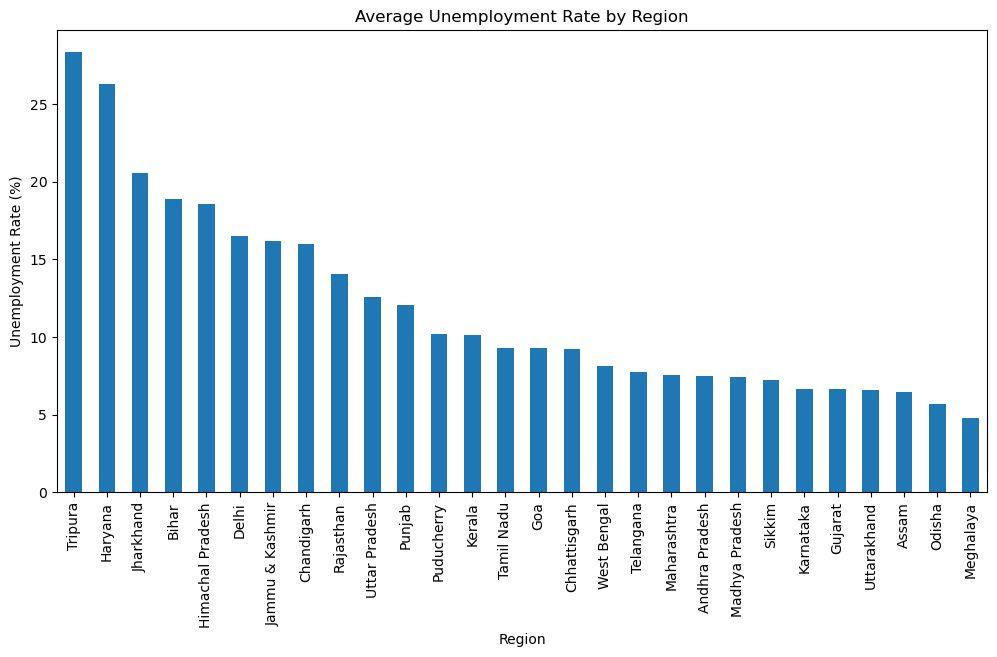

In [10]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.show()

## Monthly Unemployment Trend

Let's see how unemployment changes by month.

In [11]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation

Unemployment changes from month to month.

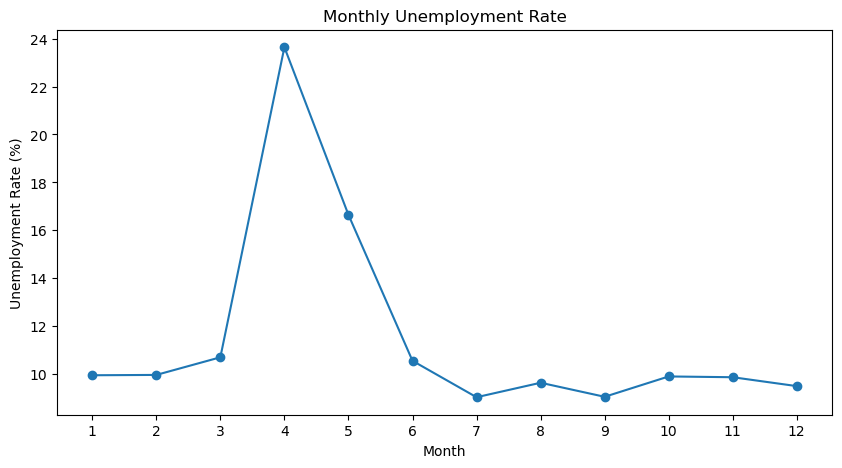

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o'
)

plt.title("Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(range(1, 13))

plt.show()

## Unemployment Over Time

Let's compare unemployment rates of three regions over time.

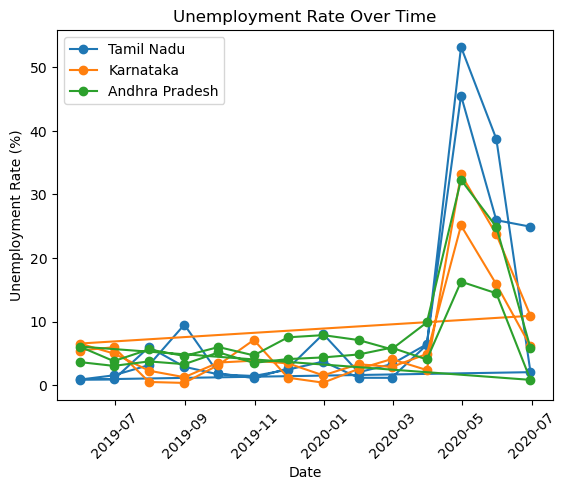

In [13]:
selected_regions = [
    'Tamil Nadu',
    'Karnataka',
    'Andhra Pradesh'
]

for region in selected_regions:

    region_data = df[df['Region'] == region]

    plt.plot(
        region_data['Date'],
        region_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=region
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.xticks(rotation=45)

plt.show()

## Top 10 Regions

Find the 10 regions with the highest average unemployment rate.

In [14]:
top_10 = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation

These 10 regions have the highest average unemployment rates.

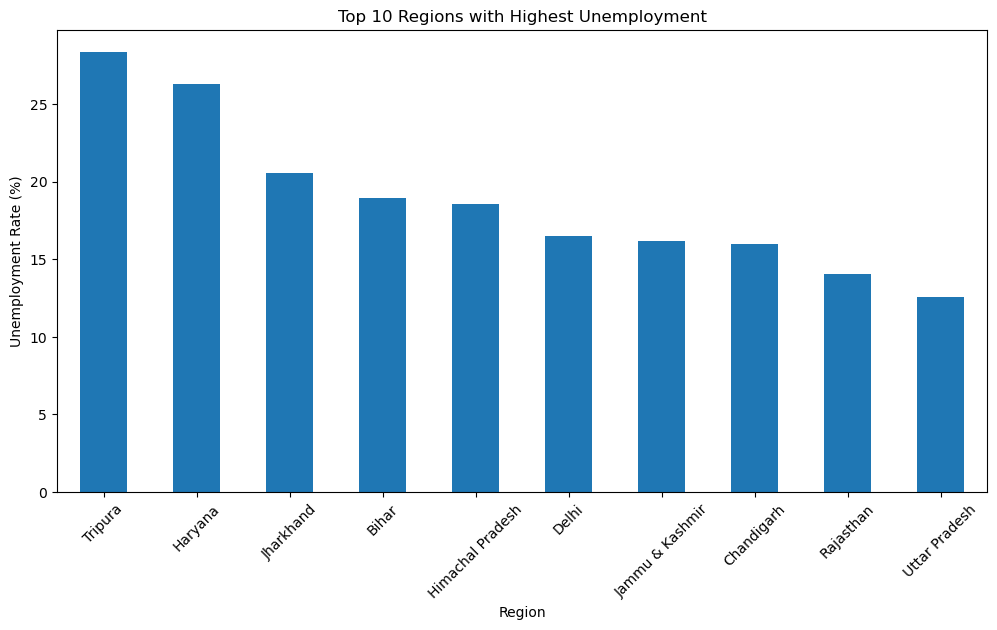

In [16]:
plt.figure(figsize=(12, 6))

top_10.plot(kind='bar')

plt.title("Top 10 Regions with Highest Unemployment")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

## Correlation Analysis

Let's check the relationship between unemployment, employment, and labour participation.

In [19]:
correlation = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


### Observation

The heatmap shows how strongly the three variables are related.

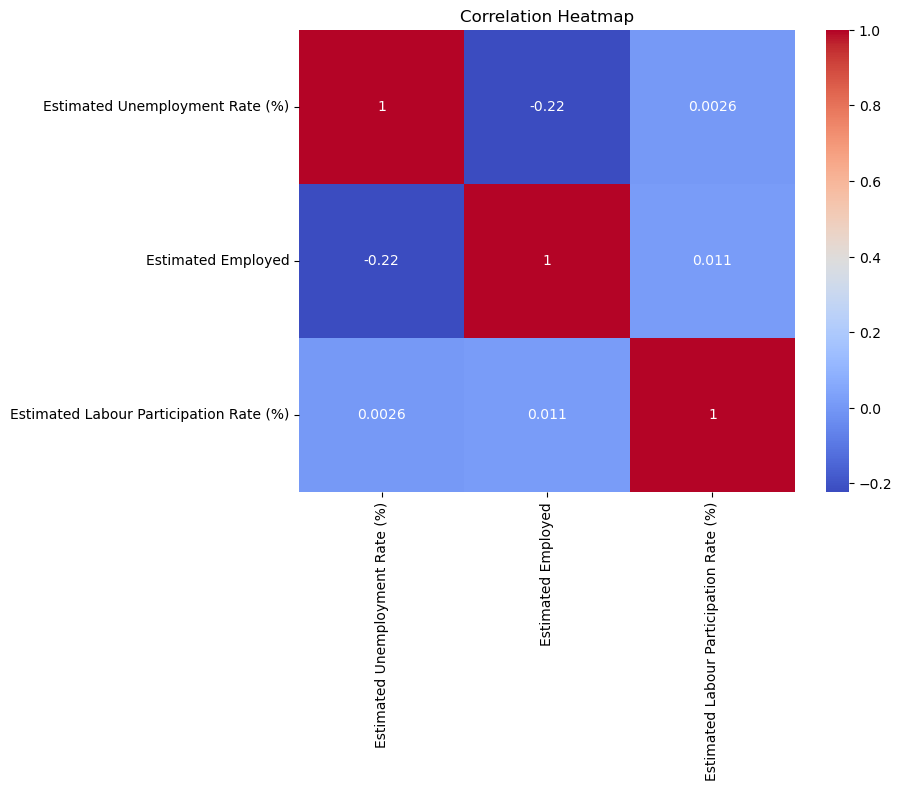

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## COVID-19 Impact

Let's compare unemployment before and after March 2020.

In [21]:
pre_covid = df[df['Date'] < '2020-03-01']

post_covid = df[df['Date'] >= '2020-03-01']

print("Pre-COVID:", len(pre_covid))
print("Post-COVID:", len(post_covid))

Pre-COVID: 536
Post-COVID: 204


## Pre-COVID vs Post-COVID

Calculate the average values for both periods.

In [22]:
columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

pre_mean = pre_covid[columns].mean()
post_mean = post_covid[columns].mean()

comparison = pd.DataFrame({
    'Pre-COVID': pre_mean,
    'Post-COVID': post_mean
})

comparison

,Pre-COVID,Post-COVID
Estimated Unemployment Rate (%),9.509534e+00,1.777436e+01
Estimated Employed,7.466028e+06,6.517203e+06
Estimated Labour Participation Rate (%),4.388612e+01,3.933005e+01


### Observation

The chart shows how unemployment and employment changed after COVID-19.

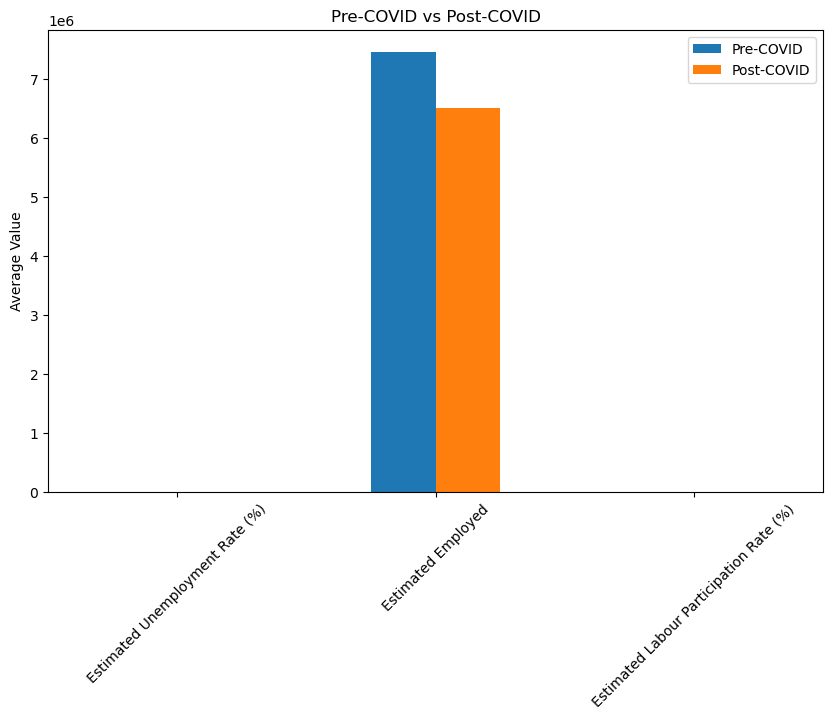

In [23]:
comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Pre-COVID vs Post-COVID")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.show()

## Conclusion

- Unemployment varied across regions.
- Unemployment changed over time.
- Some regions had higher unemployment than others.
- COVID-19 affected India's employment situation.
- Python helped us understand these trends using data and graphs.